# <center>**0Z_eda_dataset_statistics**</center>

### Table of Contents

1. **Notebook Overview**  
   - Objective of the descriptive analysis  
   - Description of the dataset
   - Role of these databases in the CNN training and evaluation pipeline  

2. **Environment Setup**  
   - Import of required libraries  
   - Definition of file paths and basic configuration  

3. **Load Databases**  
   - Load the three anonymised datasets from feather files  
   - Basic integrity checks (shape, column names, first rows)  

4. **Variable Inspection**  
   - Data types and basic cleaning  
   - Harmonisation of key variables (e.g. calcification label coding)  

5. **Descriptive Statistics for Quantitative Variables**  
   - Age computation from birth date and radiograph date  
   - Exposure Index (EI)  
   - Summary statistics (mean, SD, median, IQR, range, skewness, kurtosis)  
   - Comparison of age and EI across the three datasets  
   - Age and EI stratified by calcific tendinopathy (No / Yes)  
   - Descriptive tables for each dataset  
   - Visualisation: histograms, boxplots and violin plots by group  

6. **Descriptive Statistics for Categorical Variables**  
   - Frequency tables for sex, laterality, projection, manufacturer and acquisition settings  
   - Distribution by dataset  
   - Distribution stratified by calcification status (No / Yes)  
   - Contingency tables (e.g. sex vs calcification, projection vs calcification)
   - Visualisation: barplots by group  

7. **Temporal Distribution of Radiographs**  
   - Annual frequency tables per dataset  
   - Combined and per-dataset visualisation of radiograph counts by year  

8. **Summary and Conclusions**  
    - Global description of the study population across datasets  
    - Differences between patients with and without calcific tendinopathy  
    - Implications for model development and external validation  


### **1. Notebook Overview**

This notebook performs a descriptive statistical analysis of the anonymised clinical and imaging metadata used for training and evaluating convolutional neural networks (CNNs) in a binary classification setting (presence vs absence of rotator cuff tendon calcifications). Four datasets are analysed. 

The goal is to characterise the study population and imaging conditions in terms of age, sex, laterality, projection type, exposure index and acquisition hardware, both globally and stratified by calcification status. Quantitative variables are summarised using standard descriptive statistics and visualised with histograms, boxplots and violin plots, while categorical variables are described through frequency tables and barplots.

These descriptive results provide context for the subsequent CNN experiments, helping to understand potential sources of distribution shift between datasets (e.g. demographic or technical differences) and to interpret model performance in light of the underlying data characteristics. No patient-identifying information is used or displayed in this notebook.

### **2. Environment Setup**

In [1]:
# Environment setup: core libraries for descriptive statistics and plotting

import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

# Silence non-critical warnings (e.g. deprecations) to keep the notebook output clean
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Basic plotting style
sns.set_style("whitegrid")

# Ensure the figures directory exists
os.makedirs('Figures', exist_ok=True)

### **3. Load Databases**

In [10]:
# === Database paths (CSV format) ===
path_train_czc = 'Subsets/Subsets_main_dataset_cropped/TC_Canon_CZC_2proje_HURJC_train.csv'
path_test_czc  = 'Subsets/Subsets_main_dataset_cropped/TC_Canon_CZC_2proje_HURJC_test.csv'
path_train_rad = 'Subsets/Subsets_main_dataset_cropped/TC_Canon_RAD_2proje_HURJC_train.csv'
path_test_rad  = 'Subsets/Subsets_main_dataset_cropped/TC_Canon_RAD_2proje_HURJC_test.csv'

# === Load the four Institution 1 subsets ===
df_train_czc = pd.read_csv(path_train_czc)
df_test_czc  = pd.read_csv(path_test_czc)
df_train_rad = pd.read_csv(path_train_rad)
df_test_rad  = pd.read_csv(path_test_rad)

# === Print shapes to confirm successful loading ===
print(f"Subset 1 (Train_CZC) - Shape: {df_train_czc.shape}")
print(f"Subset 2 (Test_CZC)  - Shape: {df_test_czc.shape}")
print(f"Subset 3 (Train_RAD) - Shape: {df_train_rad.shape}")
print(f"Subset 4 (Test_RAD)  - Shape: {df_test_rad.shape}")

# === Preview columns (Head 0) ===
print("\nFirst subset (Train_CZC):")
display(df_train_czc.head(0))

print("\nSecond subset (Test_CZC):")
display(df_test_czc.head(0))

print("\nThird subset (Train_RAD):")
display(df_train_rad.head(0))

print("\nFourth subset (Test_RAD):")
display(df_test_rad.head(0))

Subset 1 (Train_CZC) - Shape: (1740, 20)
Subset 2 (Test_CZC)  - Shape: (196, 20)
Subset 3 (Train_RAD) - Shape: (1412, 20)
Subset 4 (Test_RAD)  - Shape: (200, 20)

First subset (Train_CZC):


,Unnamed: 0,NHC,epi_cod,rx_cod,proje,manufacturer,manufacturer_model,station_name,voilutfunction,birthdate,sex,ei,date_rx,label_CalTend,label_CalTend_sub,label_CalTend_supr,label_CalTend_infr,size,complentary_expl,lat_rx



Second subset (Test_CZC):


,Unnamed: 0,NHC,epi_cod,rx_cod,proje,manufacturer,manufacturer_model,station_name,voilutfunction,birthdate,sex,ei,date_rx,label_CalTend,label_CalTend_sub,label_CalTend_supr,label_CalTend_infr,size,complentary_expl,lat_rx



Third subset (Train_RAD):


,Unnamed: 0,NHC,epi_cod,rx_cod,proje,manufacturer,manufacturer_model,station_name,voilutfunction,birthdate,sex,ei,date_rx,label_CalTend,label_CalTend_sub,label_CalTend_supr,label_CalTend_infr,size,complentary_expl,lat_rx



Fourth subset (Test_RAD):


,Unnamed: 0,NHC,epi_cod,rx_cod,proje,manufacturer,manufacturer_model,station_name,voilutfunction,birthdate,sex,ei,date_rx,label_CalTend,label_CalTend_sub,label_CalTend_supr,label_CalTend_infr,size,complentary_expl,lat_rx


In [11]:
# Validation of clinical episodes vs. total samples
for df, name in zip([df_train_czc, df_test_czc, df_train_rad, df_test_rad], 
                     ['Train_CZC', 'Test_CZC', 'Train_RAD', 'Test_RAD']):
    
    n_samples = len(df)
    n_episodes = df['epi_cod'].nunique()
    n_patients = df['NHC'].nunique()
    
    print(f"{name}:")
    print(f"  - Total samples (rows): {n_samples}")
    print(f"  - Unique clinical episodes: {n_episodes}")
    print("-" * 30)

Train_CZC:
  - Total samples (rows): 1740
  - Unique clinical episodes: 870
------------------------------
Test_CZC:
  - Total samples (rows): 196
  - Unique clinical episodes: 98
------------------------------
Train_RAD:
  - Total samples (rows): 1412
  - Unique clinical episodes: 706
------------------------------
Test_RAD:
  - Total samples (rows): 200
  - Unique clinical episodes: 100
------------------------------


### **4. Variable Inspection**

In [13]:
# Check dtypes for all datasets side-by-side
display(pd.concat([
    df_train_czc.dtypes.rename("Train_CZC"),
    df_test_czc.dtypes.rename("Test_CZC"),
    df_train_rad.dtypes.rename("Train_RAD"),
    df_test_rad.dtypes.rename("Test_RAD")
], axis=1))

,Train_CZC,Test_CZC,Train_RAD,Test_RAD
Unnamed: 0,int64,int64,int64,int64
NHC,object,object,object,object
epi_cod,object,object,object,object
rx_cod,object,object,object,object
proje,object,object,object,object
manufacturer,object,object,object,object
manufacturer_model,object,object,object,object
station_name,object,object,object,object
voilutfunction,object,object,object,object
birthdate,object,object,object,object


### **5. Descriptive Statistics for Quantitative Variables**

In [14]:
def normalize_yes_no(series):
    mapping = {
        0: 'No', 1: 'Yes',
        '0': 'No', '1': 'Yes',
        'No': 'No', 'NO': 'No', 'no': 'No', 'N': 'No',
        'Sí': 'Yes', 'Si': 'Yes', 'SI': 'Yes', 'sí': 'Yes',
        'Yes': 'Yes', 'YES': 'Yes', 'yes': 'Yes',
        True: 'Yes', False: 'No'
    }
    s = series.replace(mapping)
    return pd.Categorical(s, categories=['No', 'Yes'], ordered=True)

# Apply directly to the four datasets
for df in [df_train_czc, df_test_czc, df_train_rad, df_test_rad]:
    df['label_CalTend'] = normalize_yes_no(df['label_CalTend'])

# Verification
print("Train_CZC:", df_train_czc['label_CalTend'].unique())
print("Test_CZC: ", df_test_czc['label_CalTend'].unique())
print("Train_RAD:", df_train_rad['label_CalTend'].unique())
print("Test_RAD: ", df_test_rad['label_CalTend'].unique())


Train_CZC: ['No', 'Yes']
Categories (2, object): ['No' < 'Yes']
Test_CZC:  ['No', 'Yes']
Categories (2, object): ['No' < 'Yes']
Train_RAD: ['No', 'Yes']
Categories (2, object): ['No' < 'Yes']
Test_RAD:  ['No', 'Yes']
Categories (2, object): ['No' < 'Yes']


In [15]:
def sdescriptive(df, var, round_=0, save_path=False):
    """
    Compute a set of descriptive statistics for a numeric variable in a DataFrame.

    This function calculates standard descriptive measures such as mean, standard deviation,
    median, interquartile range (IQR), range, minimum, maximum, skewness, and kurtosis.
    By default, all values are rounded to the specified number of decimals (round_). If
    a file path is provided (save_path), the resulting statistics are also saved in CSV
    and Excel formats.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing the dataset.
    var : str
        Name of the column (variable) for which descriptive statistics will be computed.
    round_ : int, optional
        Number of decimal places to which the results should be rounded. Defaults to 0.
    save_path : bool or str, optional
        If False (default), the function does not save any file. If a string is provided,
        it is used as the base path (without extension) for saving the results to CSV and
        Excel files (e.g. 'path/filename').

    Returns
    -------
    pandas.DataFrame
        A DataFrame containing the descriptive statistics for the specified variable,
        with the following metrics as rows:
        - Mean
        - Standard deviation
        - Median
        - Interquartile range (IQR)
        - Range
        - Minimum
        - Maximum
        - Skewness
        - Kurtosis (Fisher definition: normal distribution == 0)
    """

    # Basic descriptive statistics: count, mean, std, min, quartiles, max
    stats_var = df[var].describe().round(round_)

    # Interquartile range and range
    stats_var['iqr'] = stats_var['75%'] - stats_var['25%']
    stats_var['range'] = stats_var['max'] - stats_var['min']

    # Skewness and kurtosis (Fisher definition: normal == 0)
    stats_var['skew'] = df[var].skew().round(round_)
    stats_var['kurt'] = df[var].kurt().round(round_)

    # Select and reorder statistics of interest
    stats_var = stats_var.loc[
        ['mean', 'std', '50%', 'iqr', 'range', 'min', 'max', 'skew', 'kurt']
    ].to_frame('Value')

    # Rename index to English labels and rename the column to the variable name
    stats_var.index = [
        'Mean',
        'Std. deviation',
        'Median',
        'IQR',
        'Range',
        'Min',
        'Max',
        'Skewness',
        'Kurtosis'
    ]
    stats_var = stats_var.rename(columns={'Value': var})

    # Optionally save to CSV and Excel
    if save_path is not False:
        stats_var.to_csv(f'{save_path}.csv')
        stats_var.to_excel(f'{save_path}.xlsx')

    return stats_var


In [16]:
# List of DataFrames and corresponding names
bases = [df_train_czc, df_test_czc, df_train_rad, df_test_rad]
names = ['Train_CZC', 'Test_CZC', 'Train_RAD', 'Test_RAD']

# Lists to store results
stats_age_list = []
stats_ei_list = []

for df in bases:
    # === Convert date columns to datetime (errors coerced to NaT) ===
    df['birthdate'] = pd.to_datetime(df['birthdate'], errors='coerce')
    df['date_rx'] = pd.to_datetime(df['date_rx'], format='mixed', dayfirst=True, errors='coerce')

    # === Compute age in years at the time of the radiograph ===
    df['age_years'] = (df['date_rx'] - df['birthdate']).dt.days / 365.25

    # Age: keep 1 decimal
    stats_age = sdescriptive(df=df, var='age_years', round_=1)

    # EI: report as integer
    stats_ei = sdescriptive(df=df, var='ei', round_=0)

    stats_age_list.append(stats_age)
    stats_ei_list.append(stats_ei)

# Combine results into a single table for age and another for EI
df_stats_age = pd.concat(stats_age_list, axis=1)
df_stats_age.columns = names

df_stats_ei = pd.concat(stats_ei_list, axis=1)
df_stats_ei.columns = names


def _format_descriptive_table(df):
    """
    Format descriptive statistics table so that values that are
    exactly integer are displayed without a trailing '.0'.
    Non-integer values keep their decimal part.
    """
    def fmt(x):
        try:
            x_float = float(x)
        except (TypeError, ValueError):
            return x
        return int(x_float) if x_float.is_integer() else x_float

    out = df.copy()
    for col in out.columns:
        out[col] = out[col].apply(fmt)
    return out


df_stats_age_display = _format_descriptive_table(df_stats_age)
df_stats_ei_display = _format_descriptive_table(df_stats_ei)

print("Descriptive statistics – Age (years):")
display(df_stats_age_display)

print("\nDescriptive statistics – Exposure Index (EI):")
display(df_stats_ei_display)

Descriptive statistics – Age (years):


,Train_CZC,Test_CZC,Train_RAD,Test_RAD
Mean,52.7,50.8,52.0,53.3
Std. deviation,13.2,13.5,13.5,13.7
Median,51.8,50.2,51.5,51.5
IQR,18.0,17.8,17.3,14.2
Range,69.4,63.0,77.5,67.1
Min,17.3,16.4,10.9,15.3
Max,86.7,79.4,88.4,82.4
Skewness,0.0,0.0,-0.1,-0.1
Kurtosis,-0.1,-0.1,0.1,0.7



Descriptive statistics – Exposure Index (EI):


,Train_CZC,Test_CZC,Train_RAD,Test_RAD
Mean,112,119,127,124
Std. deviation,92,98,94,94
Median,86,93,105,104
IQR,129,136,144,141
Range,396,395,397,357
Min,4,5,3,7
Max,400,400,400,364
Skewness,1,1,1,1
Kurtosis,0,0,-1,0


In [17]:
# Descriptive statistics for age and EI by tendon calcification status (No / Yes) for each dataset

stats_by_tc_list = []
names = ['Train_CZC', 'Test_CZC', 'Train_RAD', 'Test_RAD']
bases = [df_train_czc, df_test_czc, df_train_rad, df_test_rad]

for df in bases:
    df_valid = df.copy()

    # Ensure age_years exists (safeguard in case this cell is run independently)
    if 'age_years' not in df_valid.columns:
        df_valid['birthdate'] = pd.to_datetime(df_valid['birthdate'], errors='coerce')
        df_valid['date_rx'] = pd.to_datetime(df_valid['date_rx'], format='mixed', dayfirst=True, errors='coerce')
        df_valid['age_years'] = (df_valid['date_rx'] - df_valid['birthdate']).dt.days / 365.25

    # Drop rows with missing values in age, EI or label
    df_valid = df_valid.dropna(subset=['age_years', 'ei', 'label_CalTend'])

    # Group by presence of calcification (label_CalTend: 'No' / 'Yes')
    # Age: keep 1 decimal (continuous clinical variable)
    stats_age_tc = df_valid.groupby('label_CalTend').apply(
        lambda g: sdescriptive(g, var='age_years', round_=1),
        include_groups=False
    )

    # EI: integer-level reporting (technical index)
    stats_ei_tc = df_valid.groupby('label_CalTend').apply(
        lambda g: sdescriptive(g, var='ei', round_=0),
        include_groups=False
    )

    # Combine age and EI statistics side by side
    df_stats_edad_ei_tc = pd.concat(
        [stats_age_tc, stats_ei_tc],
        axis=1,
        keys=['Age (years)', 'Exposure Index (EI)']
    )

    # Apply the same formatting as in the global tables (remove .0 when exact integer)
    df_stats_edad_ei_tc = _format_descriptive_table(df_stats_edad_ei_tc)

    stats_by_tc_list.append(df_stats_edad_ei_tc)

# Display results for each dataset
for name, df_stats in zip(names, stats_by_tc_list):
    print(f"\nDescriptive statistics by tendon calcification status – {name}")
    display(df_stats)


Descriptive statistics by tendon calcification status – Train_CZC


Age (years) Exposure Index (EI)
                               age_years                  ei
label_CalTend                                               
No            Mean                  53.1                 119
              Std. deviation        15.4                  96
              Median                53.3                  96
              IQR                   22.6                 134
              Range                 69.4                 396
              Min                   17.3                   4
              Max                   86.7                 400
              Skewness              -0.2                   1
              Kurtosis              -0.5                   0
Yes           Mean                  52.4                 104
              Std. deviation        10.5                  89
              Median                50.8                  79
              IQR                   14.4                 120
              Range                 55.0                 395
              Min                   29.7                   5
              Max                   84.7                 400
              Skewness               0.7                   1
              Kurtosis               0.2                   0


Descriptive statistics by tendon calcification status – Test_CZC


Age (years) Exposure Index (EI)
                               age_years                  ei
label_CalTend                                               
No            Mean                  49.3                 115
              Std. deviation        15.2                  91
              Median                50.7                  86
              IQR                   19.5                 138
              Range                 62.5                 315
              Min                   16.4                   5
              Max                   78.9                 320
              Skewness              -0.2                   1
              Kurtosis              -0.5                  -1
Yes           Mean                  52.4                 124
              Std. deviation        11.6                 105
              Median                49.8                 103
              IQR                   17.4                 131
              Range                 43.9                 394
              Min                   35.5                   6
              Max                   79.4                 400
              Skewness               0.7                   1
              Kurtosis              -0.3                   0


Descriptive statistics by tendon calcification status – Train_RAD


Age (years) Exposure Index (EI)
                               age_years                  ei
label_CalTend                                               
No            Mean                  52.6                 126
              Std. deviation        16.0                  91
              Median                53.4                 105
              IQR                   20.8                 133
              Range                 77.5                 344
              Min                   10.9                   6
              Max                   88.4                 350
              Skewness              -0.3                   1
              Kurtosis              -0.3                  -1
Yes           Mean                  51.5                 127
              Std. deviation        10.3                  97
              Median                50.2                 104
              IQR                   13.4                 151
              Range                 57.0                 397
              Min                   27.3                   3
              Max                   84.3                 400
              Skewness               0.5                   1
              Kurtosis               0.0                  -1


Descriptive statistics by tendon calcification status – Test_RAD


Age (years) Exposure Index (EI)
                               age_years                  ei
label_CalTend                                               
No            Mean                  52.2                 123
              Std. deviation        16.0                  88
              Median                51.5                 106
              IQR                   17.8                 102
              Range                 67.1                 353
              Min                   15.3                  11
              Max                   82.4                 364
              Skewness              -0.3                   1
              Kurtosis               0.1                   1
Yes           Mean                  54.5                 124
              Std. deviation        10.9                 100
              Median                51.5                  96
              IQR                   13.7                 172
              Range                 44.8                 341
              Min                   37.2                   7
              Max                   82.0                 348
              Skewness               1.1                   1
              Kurtosis               0.6                  -1

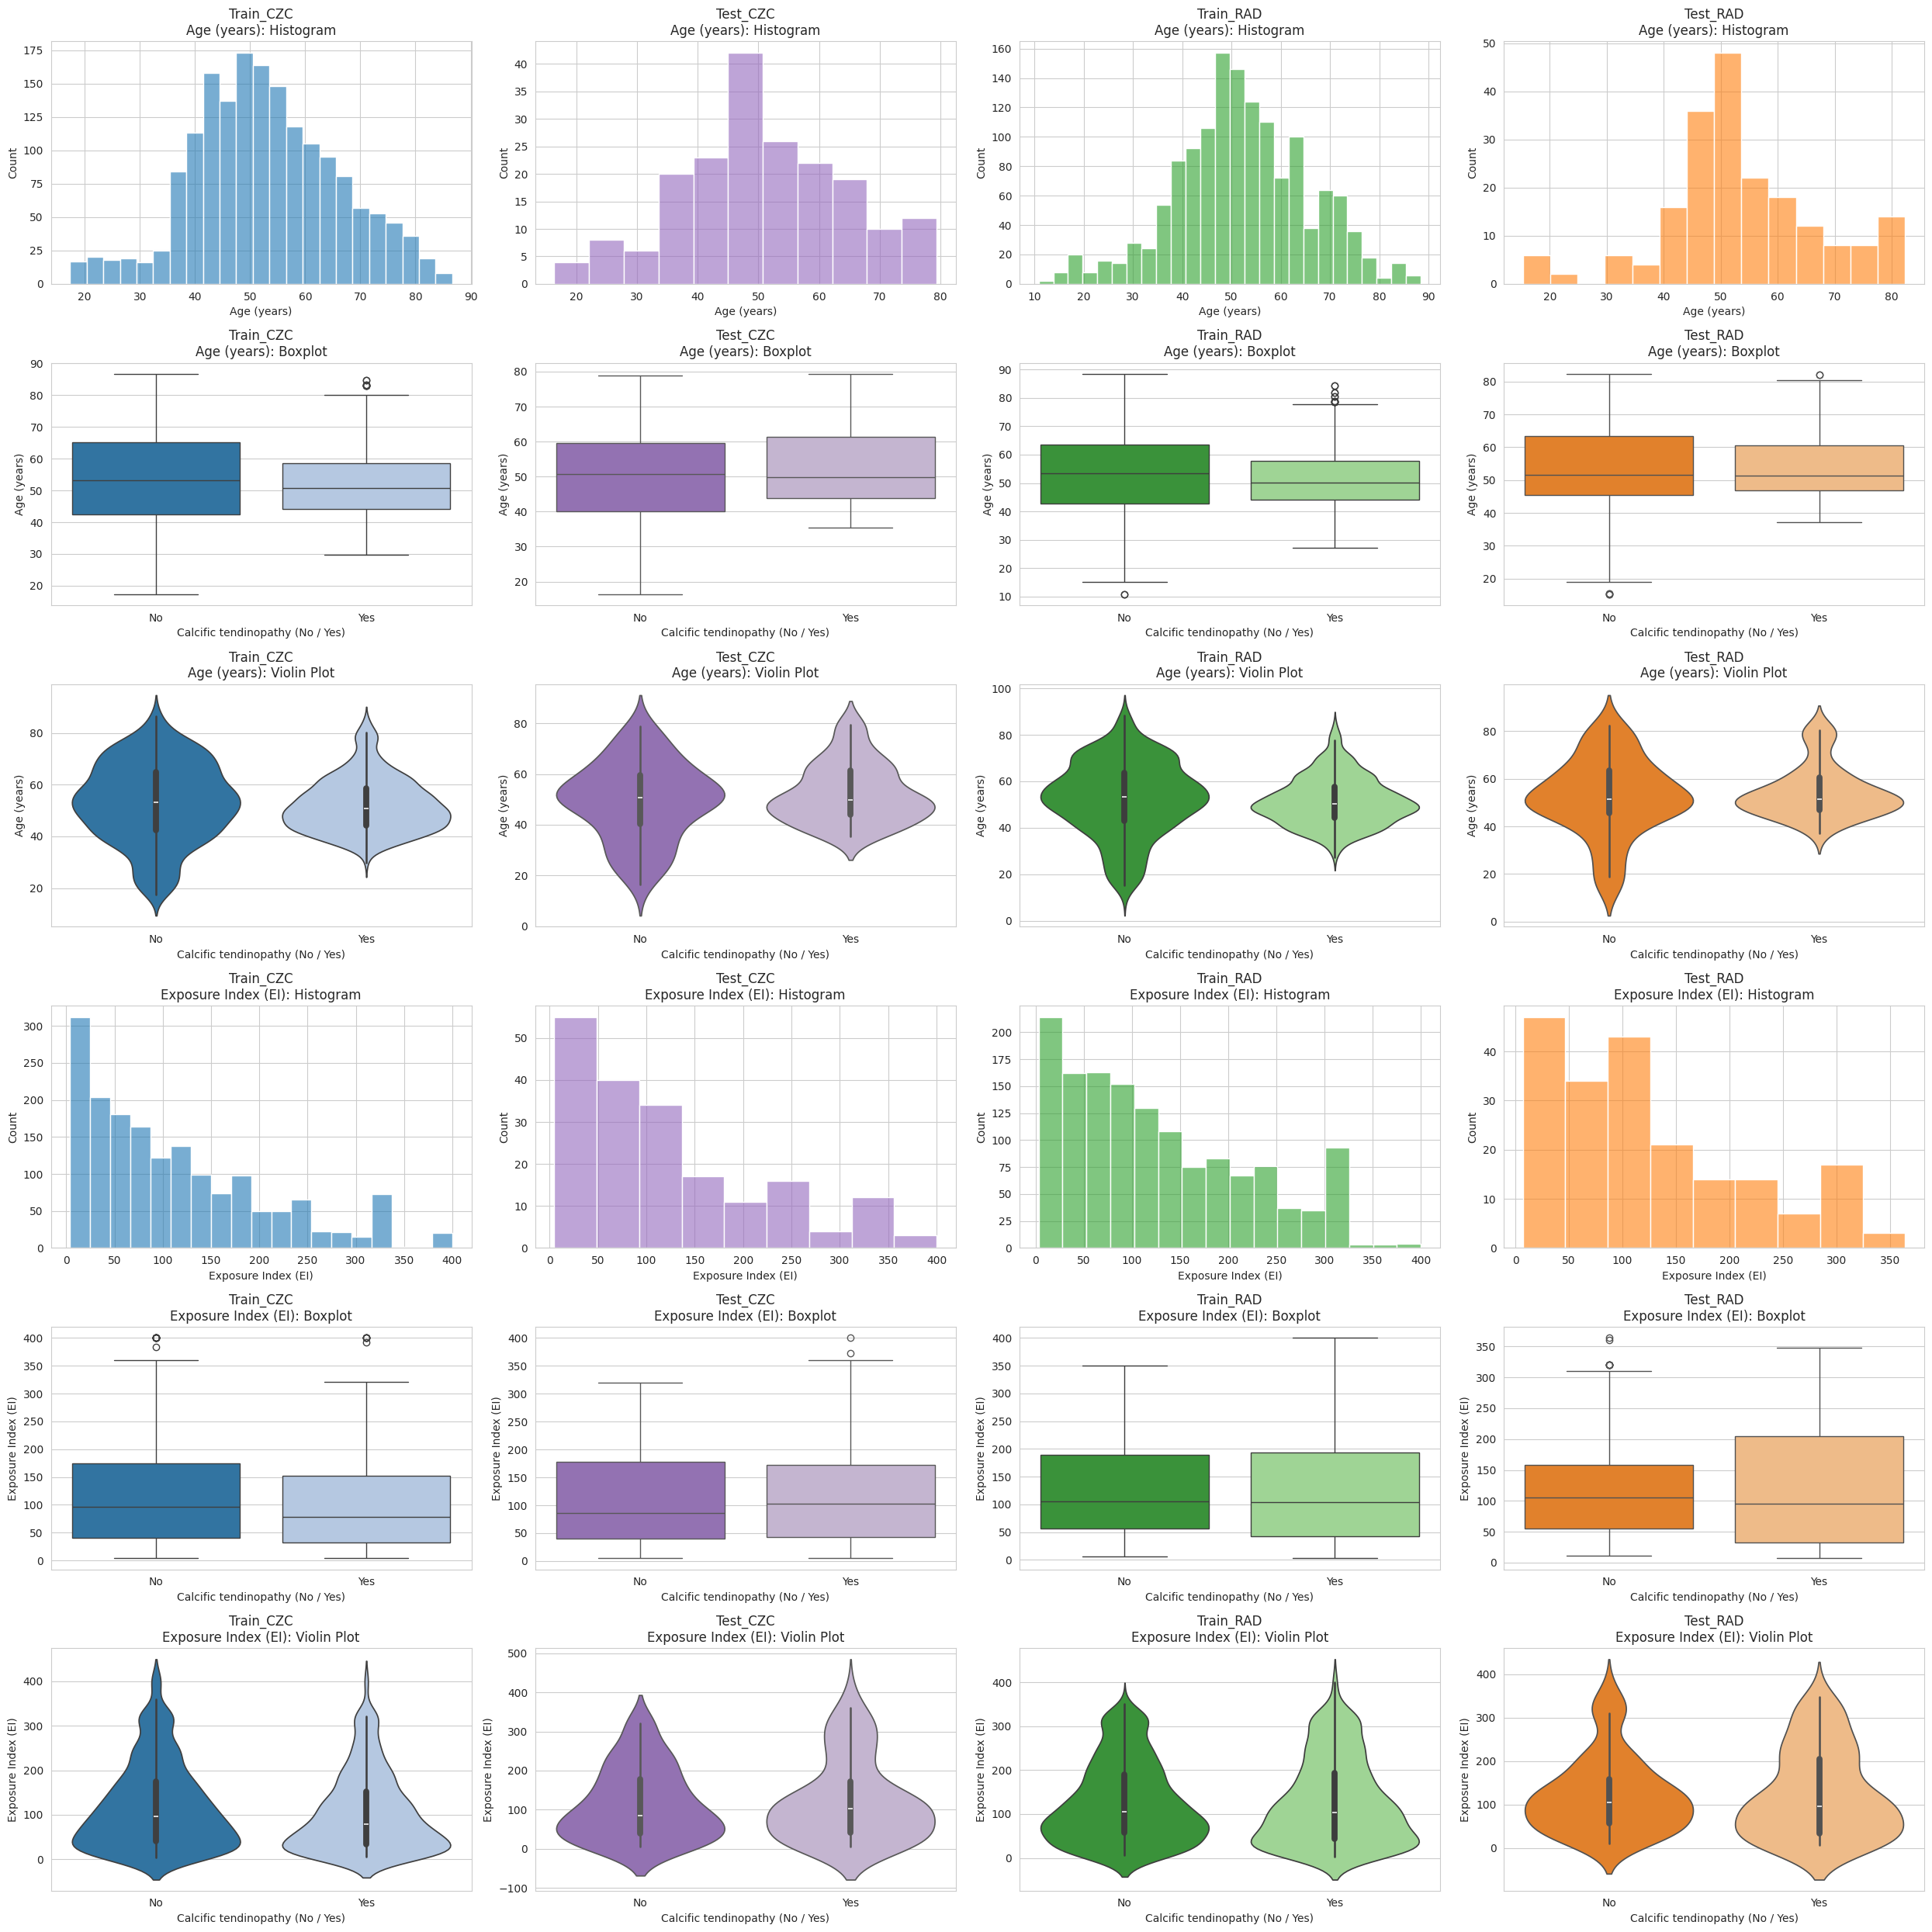

In [18]:
# Ensure consistent categorical order for calcification label
for df in [df_train_czc, df_test_czc, df_train_rad, df_test_rad]:
    df['label_CalTend'] = pd.Categorical(
        df['label_CalTend'],
        categories=['No', 'Yes'],
        ordered=True
    )

# Color palettes per dataset (CZC in Blues/Purples, RAD in Greens/Oranges)
palette_czc_train = ['#1f77b4', '#aec7e8']  # Blues
palette_czc_test  = ['#9467bd', '#c5b0d5']  # Purples
palette_rad_train = ['#2ca02c', '#98df8a']  # Greens
palette_rad_test  = ['#ff7f0e', '#ffbb78']  # Oranges

palettes = [palette_czc_train, palette_czc_test, palette_rad_train, palette_rad_test]
bases = [df_train_czc, df_test_czc, df_train_rad, df_test_rad]
base_names = ['Train_CZC', 'Test_CZC', 'Train_RAD', 'Test_RAD']

# Global figure: 6 rows (Age/EI × 3 plot types), 4 columns (one per subset)
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(25, 25))
sns.set_style('whitegrid')

# Create folders to save individual figures
for name in base_names:
    os.makedirs(f'Figures/{name}', exist_ok=True)

# Map variable names to axis labels
var_label_map = {'age_years': 'Age (years)', 'ei': 'Exposure Index (EI)'}

# Build plots for each dataset
for col, (df, name, palette) in enumerate(zip(bases, base_names, palettes)):

    df_plot = df.copy()

    # Ensure age_years exists and remove invalid rows
    if 'age_years' not in df_plot.columns:
        df_plot['birthdate'] = pd.to_datetime(df_plot['birthdate'], errors='coerce')
        df_plot['date_rx'] = pd.to_datetime(df_plot['date_rx'], format='mixed', dayfirst=True, errors='coerce')
        df_plot['age_years'] = (df_plot['date_rx'] - df_plot['birthdate']).dt.days / 365.25

    df_plot = df_plot.dropna(subset=['age_years', 'ei', 'label_CalTend'])
    palette_dict = {'No': palette[0], 'Yes': palette[1]}

    # Plot definitions
    plots = [
        (0, 'age_years', 'Histogram', lambda ax: sns.histplot(df_plot['age_years'], color=palette[0], alpha=0.6, kde=False, ax=ax)),
        (1, 'age_years', 'Boxplot', lambda ax: sns.boxplot(data=df_plot, x='label_CalTend', y='age_years', order=['No', 'Yes'], hue='label_CalTend', palette=palette_dict, dodge=False, ax=ax)),
        (2, 'age_years', 'Violin Plot', lambda ax: sns.violinplot(data=df_plot, x='label_CalTend', y='age_years', order=['No', 'Yes'], hue='label_CalTend', palette=palette_dict, dodge=False, inner='box', ax=ax)),
        (3, 'ei', 'Histogram', lambda ax: sns.histplot(df_plot['ei'], color=palette[0], alpha=0.6, kde=False, ax=ax)),
        (4, 'ei', 'Boxplot', lambda ax: sns.boxplot(data=df_plot, x='label_CalTend', y='ei', order=['No', 'Yes'], hue='label_CalTend', palette=palette_dict, dodge=False, ax=ax)),
        (5, 'ei', 'Violin Plot', lambda ax: sns.violinplot(data=df_plot, x='label_CalTend', y='ei', order=['No', 'Yes'], hue='label_CalTend', palette=palette_dict, dodge=False, inner='box', ax=ax)),
    ]

    for row, var, plot_type, plot_func in plots:
        ax = axes[row, col]
        plot_func(ax)
        if ax.legend_ is not None: ax.legend_.remove()

        y_label = var_label_map[var]
        if 'Histogram' in plot_type:
            ax.set_xlabel(y_label); ax.set_ylabel('Count')
        else:
            ax.set_xlabel('Calcific tendinopathy (No / Yes)'); ax.set_ylabel(y_label)
        
        ax.set_title(f'{name}\n{y_label}: {plot_type}')

        # Save individual figure
        fig_ind, ax_ind = plt.subplots(figsize=(6, 4))
        try:
            plot_func(ax_ind)
            if ax_ind.legend_ is not None: ax_ind.legend_.remove()
            ax_ind.set_title(f'{name} – {y_label}: {plot_type}')
            fig_ind.tight_layout()
            fig_ind.savefig(f'Figures/{name}/{var}_{plot_type.replace(" ", "_")}.png', dpi=300)
            plt.close(fig_ind)
        except: plt.close(fig_ind)

plt.tight_layout()
plt.show()

### **6. Descriptive Statistics for Quantitative Variables**

In [19]:
def freqtab(df, column, decimals=1, title="", print_=False):
    """
    Create a frequency table (count and percentage) for a categorical variable.

    The function returns a table with the absolute count and the percentage
    of each category in the specified column. Missing values are labeled as 'NA'.
    A final 'TOTAL' row is added with the overall count and 100% in the percentage column.

    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame containing the data.
    column : str
        Column name for which the frequency table is computed.
    decimals : int, optional
        Number of decimal places for the percentages. Default is 1.
    title : str, optional
        Text printed before showing the table. Default is an empty string.
    print_ : bool, optional
        If True, the resulting table is displayed. Default is False.

    Returns
    -------
    pandas.DataFrame
        Frequency table with:
        - 'count (n)': absolute frequencies
        - 'percentage (%)': percentages over the total (including NA)
        plus a final 'TOTAL' row.
    """
    df2 = df.copy()

    # Ensure the column exists
    if column not in df2.columns:
        raise KeyError(f"Column '{column}' not found in DataFrame.")

    # Work with a single Series, treating missing values as 'NA'
    series = df2[column]

    # If categorical, add 'NA' to categories to ensure it is represented
    if isinstance(series.dtype, pd.CategoricalDtype):
        series = series.cat.add_categories('NA').fillna('NA')
    else:
        series = series.fillna('NA')

    # Frequency counts
    counts = series.value_counts(dropna=False)
    total = counts.sum()

    # Build table
    table = pd.DataFrame({
        'count (n)': counts,
        'percentage (%)': (counts / total * 100).round(decimals)
    })

    # Add TOTAL row with exact 100% in the percentage column
    total_row = pd.DataFrame(
        {'count (n)': [total],
         'percentage (%)': [100.0]},
        index=['TOTAL']
    )
    table = pd.concat([table, total_row], axis=0)

    # Set index name to the variable name
    table = table.rename_axis(column)

    if title:
        print(title)
    if print_:
        display(table)

    return table


In [20]:
# List of categorical variables to analyse
categorical_vars = [
    'sex',
    'label_CalTend',
    'lat_rx',
    'proje',
    'manufacturer',
    'manufacturer_model',
    'station_name',
    'voilutfunction',
    'complentary_expl'
]

# List of (DataFrame, name) pairs for the four subsets
bases = [
    (df_train_czc, 'Train_CZC'),
    (df_test_czc, 'Test_CZC'),
    (df_train_rad, 'Train_RAD'),
    (df_test_rad, 'Test_RAD')
]

# Frequency tables for overall sample and by calcification status
for df, name in bases:
    print(f"\n{name} — Overall sample")
    print("-" * 60)
    for col in categorical_vars:
        if col in df.columns:
            freqtab(
                df=df,
                column=col,
                decimals=1,
                title=f'{col} (overall sample)',
                print_=True
            )

    print(f"\n{name} — Patients with calcific tendinopathy (TC = Yes)")
    print("-" * 60)
    df_yes = df[df['label_CalTend'] == 'Yes']
    for col in categorical_vars:
        if col in df_yes.columns:
            freqtab(
                df=df_yes,
                column=col,
                decimals=1,
                title=f'{col} (TC = Yes)',
                print_=True
            )

    print(f"\n{name} — Patients without calcific tendinopathy (TC = No)")
    print("-" * 60)
    df_no = df[df['label_CalTend'] == 'No']
    for col in categorical_vars:
        if col in df_no.columns:
            freqtab(
                df=df_no,
                column=col,
                decimals=1,
                title=f'{col} (TC = No)',
                print_=True
            )


Train_CZC — Overall sample
------------------------------------------------------------
sex (overall sample)


,count (n),percentage (%)
sex,,
F,1006,57.8
M,734,42.2
TOTAL,1740,100.0


label_CalTend (overall sample)


,count (n),percentage (%)
label_CalTend,,
Yes,874,50.2
No,866,49.8
NA,0,0.0
TOTAL,1740,100.0


lat_rx (overall sample)


...

,count (n),percentage (%)
station_name,,
RADIOLOGIA-HP,100,100.0
TOTAL,100,100.0


voilutfunction (TC = No)


,count (n),percentage (%)
voilutfunction,,
LINEAR,100,100.0
TOTAL,100,100.0


complentary_expl (TC = No)


,count (n),percentage (%)
complentary_expl,,
Sí,80,80.0
No,20,20.0
TOTAL,100,100.0


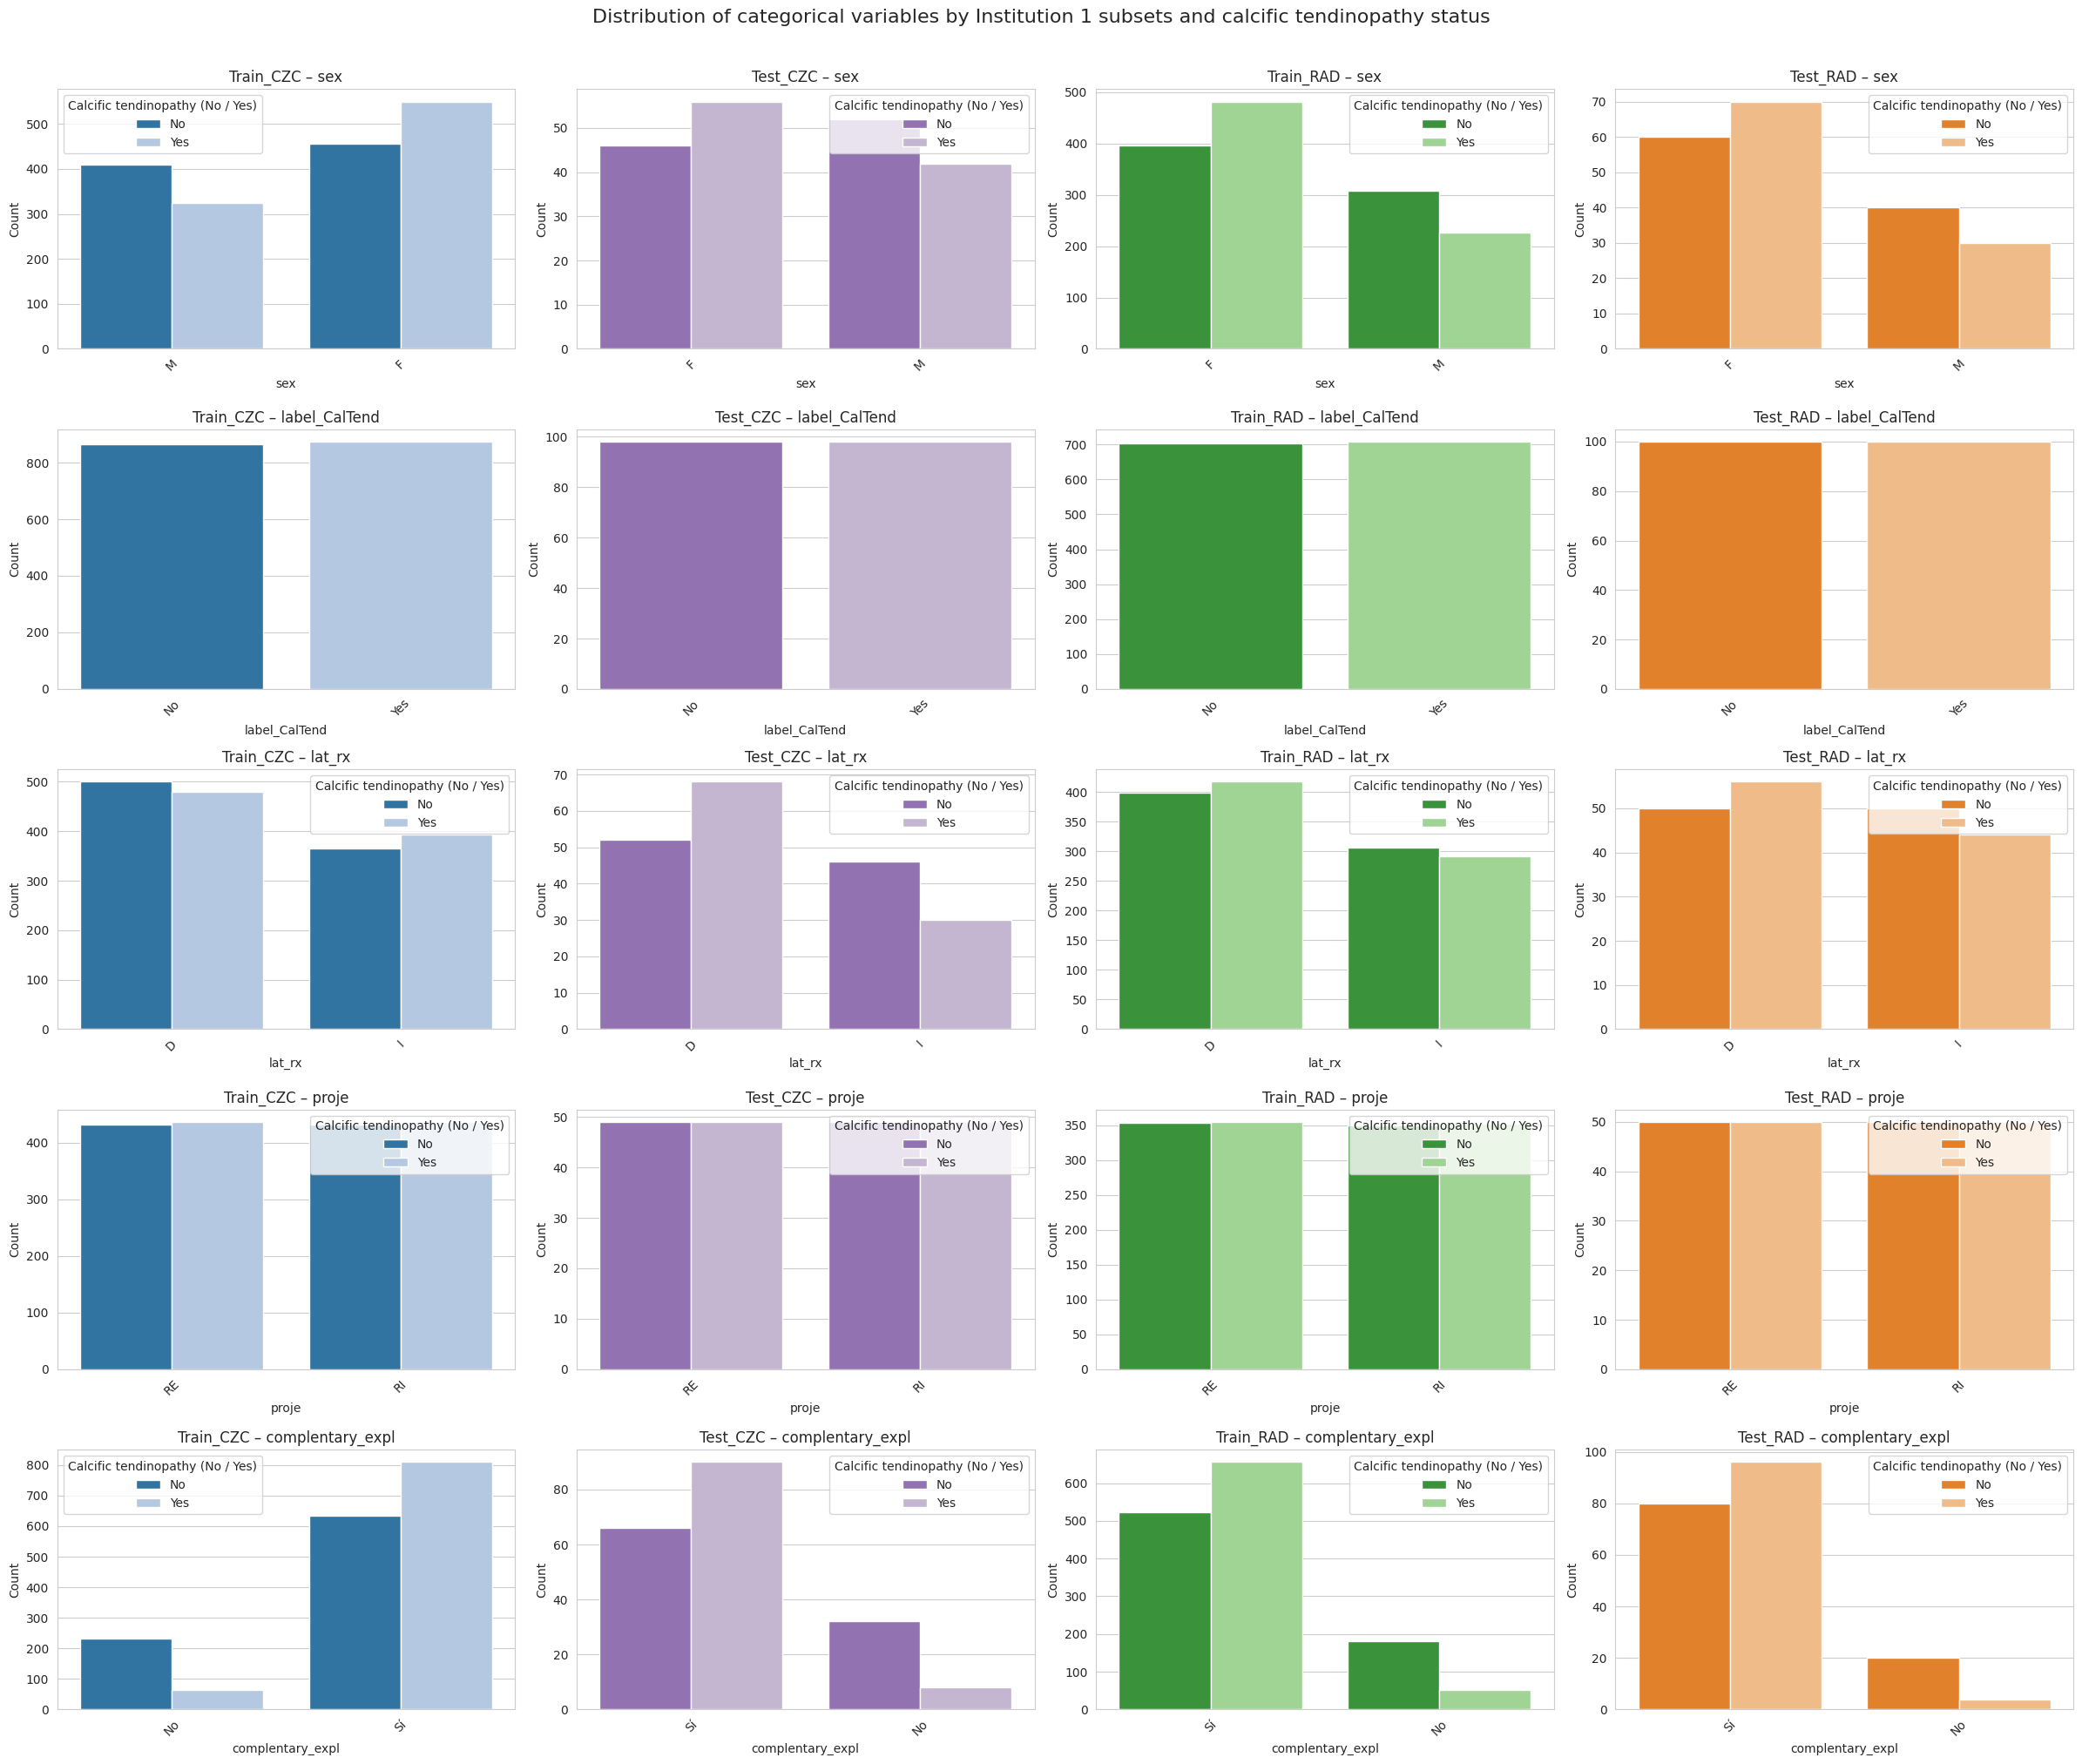

In [21]:
# Ensure consistent order for categorical labels across all four datasets

for df in [df_train_czc, df_test_czc, df_train_rad, df_test_rad]:
    df['label_CalTend'] = pd.Categorical(
        df['label_CalTend'],
        categories=['No', 'Yes'],
        ordered=True
    )

    if 'lat_rx' in df.columns:
        df['lat_rx'] = pd.Categorical(
            df['lat_rx'],
            categories=['D', 'I'],
            ordered=True
        )

# Color palettes per dataset (matching previous visual identity)
palette_czc_train = ['#1f77b4', '#aec7e8']
palette_czc_test  = ['#9467bd', '#c5b0d5']
palette_rad_train = ['#2ca02c', '#98df8a']
palette_rad_test  = ['#ff7f0e', '#ffbb78']

# Categorical variables to analyse
categorical_vars = [
    'sex',
    'label_CalTend',
    'lat_rx',
    'proje',
    'manufacturer',
    'manufacturer_model',
    'station_name',
    'voilutfunction',
    'complentary_expl'
]

# List of datasets and corresponding palettes
bases = [
    (df_train_czc, 'Train_CZC', palette_czc_train),
    (df_test_czc,  'Test_CZC',  palette_czc_test),
    (df_train_rad, 'Train_RAD', palette_rad_train),
    (df_test_rad,  'Test_RAD',  palette_rad_test)
]

# Keep only variables with > 1 non-null category in at least one dataset
valid_categories = []
for var in categorical_vars:
    if any(df[var].nunique(dropna=True) > 1 for df, _, _ in bases if var in df.columns):
        valid_categories.append(var)

nrows = len(valid_categories)
ncols = 4  # updated to 4 columns for our 4 subsets

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(24, 4 * nrows),
    sharey=False
)

fig.suptitle(
    "Distribution of categorical variables by Institution 1 subsets and calcific tendinopathy status",
    fontsize=16,
    y=1.01
)

if nrows == 1:
    axes = np.expand_dims(axes, axis=0)

sns.set_style('whitegrid')

for row_idx, var in enumerate(valid_categories):
    for col_idx, (df, name, palette) in enumerate(bases):
        ax = axes[row_idx, col_idx]

        if var not in df.columns:
            ax.set_visible(False)
            continue

        try:
            sns.countplot(
                data=df,
                x=var,
                hue='label_CalTend',
                palette={'No': palette[0], 'Yes': palette[1]},
                ax=ax
            )
            ax.set_title(f'{name} – {var}')
            ax.set_xlabel(var)
            ax.set_ylabel('Count')
            ax.tick_params(axis='x', rotation=45)

            # Only add legend if there are labeled artists
            handles, labels = ax.get_legend_handles_labels()
            if labels:
                ax.legend(title='Calcific tendinopathy (No / Yes)', loc='best')
            else:
                if ax.legend_ is not None:
                    ax.legend_.remove()

        except Exception as e:
            ax.set_visible(False)
            print(f'Error plotting {var} in {name}: {e}')

plt.tight_layout()
plt.show()

### **7. Temporal Distribution of Radiographs**


Train_CZC – Annual frequency table
--------------------------------------------------
col_0  Count  Percentage (%)
2021     224           12.90
2022     370           21.31
2023     646           37.21
2024     496           28.57
TOTAL   1736          100.00

Test_CZC – Annual frequency table
--------------------------------------------------
col_0  Count  Percentage (%)
2021      18            9.18
2022      36           18.37
2023      74           37.76
2024      68           34.69
TOTAL    196          100.00

Train_RAD – Annual frequency table
--------------------------------------------------
col_0  Count  Percentage (%)
2014       4            0.28
2018       6            0.43
2019       4            0.28
2020      12            0.85
2021     156           11.06
2022     272           19.29
2023     568           40.28
2024     388           27.52
TOTAL   1410          100.00

Test_RAD – Annual frequency table
--------------------------------------------------
col_0  Count  Pe

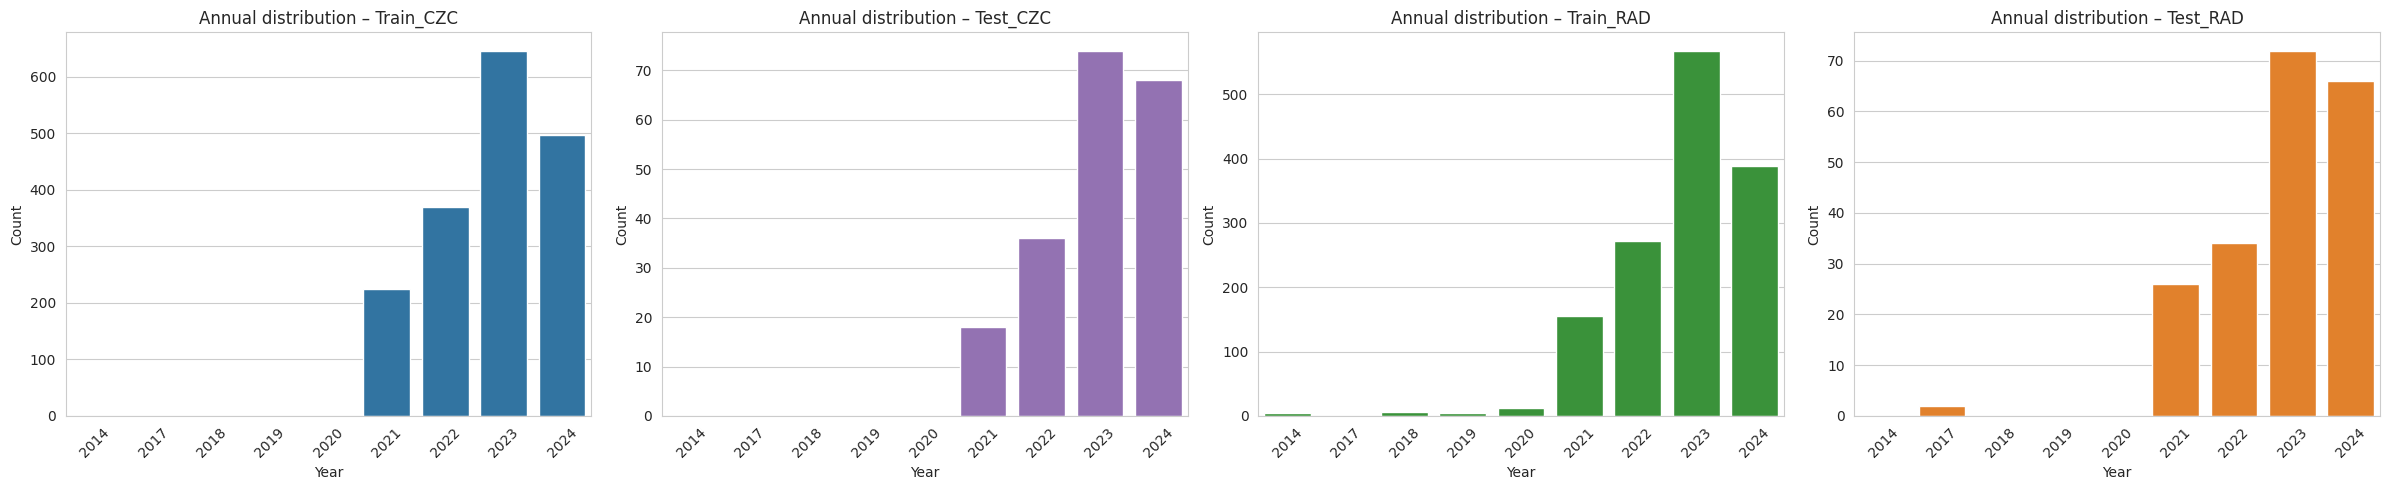

In [22]:
# Palettes and dataset names for the four subsets
palette_czc_train = '#1f77b4'
palette_czc_test  = '#9467bd'
palette_rad_train = '#2ca02c'
palette_rad_test  = '#ff7f0e'

palettes = [palette_czc_train, palette_czc_test, palette_rad_train, palette_rad_test]
names = ['Train_CZC', 'Test_CZC', 'Train_RAD', 'Test_RAD']
bases = [df_train_czc, df_test_czc, df_train_rad, df_test_rad]

# Output folder
output_folder = 'Figures/Descriptive_statistics'
os.makedirs(output_folder, exist_ok=True)

# Global dataframe for plotting
df_all_plot = pd.DataFrame()

# Annual frequency tables per dataset
for df, name, color in zip(bases, names, palettes):
    # Work on a copy to avoid modifying the original DataFrame
    df_tmp = df.copy()

    # Parse dates and drop invalid ones
    df_tmp['date_rx'] = pd.to_datetime(df_tmp['date_rx'], errors='coerce')
    df_tmp = df_tmp.dropna(subset=['date_rx']).copy()

    # Extract year as string
    df_tmp['date_rx_year'] = df_tmp['date_rx'].dt.year.astype(int).astype(str)

    # Frequency table by year
    table = pd.crosstab(index=df_tmp['date_rx_year'], columns='Count')
    table['Percentage (%)'] = (table['Count'] / table['Count'].sum() * 100).round(2)

    # Add TOTAL row
    total_row = pd.DataFrame(
        data=[[table['Count'].sum(), 100.00]],
        columns=table.columns,
        index=['TOTAL']
    )
    table = pd.concat([table, total_row])

    # Show table in the notebook
    print(f"\n{name} – Annual frequency table")
    print("-" * 50)
    print(table)

    # Save table
    table.to_csv(f"{output_folder}/{name}_annual_frequency.csv", index=True)
    table.to_excel(f"{output_folder}/{name}_annual_frequency.xlsx", index=True)

    # Append to global plotting dataframe
    tmp = df_tmp[['date_rx_year']].copy()
    tmp['base'] = name
    df_all_plot = pd.concat([df_all_plot, tmp], ignore_index=True)

# Facet plots: one panel per dataset
sns.set_style('whitegrid')

# Ensure chronological order of years on the x-axis
year_order = sorted(df_all_plot['date_rx_year'].unique(), key=lambda x: int(x))

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(names),
    figsize=(6 * len(names), 5),
    sharey=False
)

# Make axes iterable
if len(names) == 1:
    axes = [axes]

for ax, name, color in zip(axes, names, palettes):
    df_sub = df_all_plot[df_all_plot['base'] == name]

    sns.countplot(
        data=df_sub,
        x='date_rx_year',
        order=year_order,
        color=color,
        ax=ax
    )

    ax.set_title(f'Annual distribution – {name}')
    ax.set_xlabel('Year')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f"{output_folder}/date_rx_annual_countplot_facets_by_base.png", dpi=300)
plt.show()

### **8. Summary and Conclusions**

This notebook provides a descriptive overview of the three anonymised clinical and imaging datasets used in the experiments, from Institution 1. Across all databases, the population spans a wide adult age range with comparable central tendencies, and a balanced representation of sexes and radiographic laterality. The EI and acquisition-related variables show that images were acquired under reasonably consistent technical conditions within each database, although some differences between institutions and acquisition systems are evident.

When stratifying by calcific tendinopathy status, patients with and without tendon calcifications showed broadly similar age distributions, and no extreme deviations were observed in EI or basic acquisition parameters between groups. The distributions of projection type, manufacturer and station name reflect the clinical workflows and equipment installed in each centre rather than systematic differences between calcified and non-calcified cases. Importantly, all descriptive summaries were computed on fully anonymised data, without exposing direct identifiers or potentially re-identifying combinations.

The temporal analysis of radiograph counts by year highlights how case accrual varies across datasets and time, which is relevant for understanding potential temporal shifts in clinical practice or acquisition protocols. Together, these descriptive findings provide essential context for the CNN experiments: they clarify the demographic and technical landscape in which the models were trained and evaluated, help to interpret performance differences between internal and external tests, and support a cautious assessment of how far the learned models can be expected to generalise beyond the specific populations and acquisition conditions represented here.